In [ ]:
#ddpg

In [ ]:
import math
from typing import Optional

import numpy as np

import gym
from gym import spaces
from gym.envs.classic_control import utils
from gym.error import DependencyNotInstalled

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pickle

In [ ]:
class Continuous_MountainCarEnv_Custom(gym.Env):
    """
    ### Description
    The Mountain Car MDP is a deterministic MDP that consists of a car placed stochastically
    at the bottom of a sinusoidal valley, with the only possible actions being the accelerations
    that can be applied to the car in either direction. The goal of the MDP is to strategically
    accelerate the car to reach the goal state on top of the right hill. There are two versions
    of the mountain car domain in gym: one with discrete actions and one with continuous.
    This version is the one with continuous actions.
    This MDP first appeared in [Andrew Moore's PhD Thesis (1990)](https://www.cl.cam.ac.uk/techreports/UCAM-CL-TR-209.pdf)
    ```
    @TECHREPORT{Moore90efficientmemory-based,
        author = {Andrew William Moore},
        title = {Efficient Memory-based Learning for Robot Control},
        institution = {University of Cambridge},
        year = {1990}
    }
    ```
    ### Observation Space
    The observation is a `ndarray` with shape `(2,)` where the elements correspond to the following:
    | Num | Observation                          | Min  | Max | Unit         |
    |-----|--------------------------------------|------|-----|--------------|
    | 0   | position of the car along the x-axis | -Inf | Inf | position (m) |
    | 1   | velocity of the car                  | -Inf | Inf | position (m) |
    ### Action Space
    The action is a `ndarray` with shape `(1,)`, representing the directional force applied on the car.
    The action is clipped in the range `[-1,1]` and multiplied by a power of 0.0015.
    ### Transition Dynamics:
    Given an action, the mountain car follows the following transition dynamics:
    *velocity<sub>t+1</sub> = velocity<sub>t+1</sub> + force * self.power - 0.0025 * cos(3 * position<sub>t</sub>)*
    *position<sub>t+1</sub> = position<sub>t</sub> + velocity<sub>t+1</sub>*
    where force is the action clipped to the range `[-1,1]` and power is a constant 0.0015.
    The collisions at either end are inelastic with the velocity set to 0 upon collision with the wall.
    The position is clipped to the range [-1.2, 0.6] and velocity is clipped to the range [-0.07, 0.07].
    ### Reward
    A negative reward of *-0.1 * action<sup>2</sup>* is received at each timestep to penalise for
    taking actions of large magnitude. If the mountain car reaches the goal then a positive reward of +100
    is added to the negative reward for that timestep.
    ### Starting State
    The position of the car is assigned a uniform random value in `[-0.6 , -0.4]`.
    The starting velocity of the car is always assigned to 0.
    ### Episode End
    The episode ends if either of the following happens:
    1. Termination: The position of the car is greater than or equal to 0.45 (the goal position on top of the right hill)
    2. Truncation: The length of the episode is 999.
    ### Arguments
    ```
    gym.make('MountainCarContinuous-v0')
    ```
    ### Version History
    * v0: Initial versions release (1.0.0)
    """

    metadata = {
        "render_modes": ["human", "rgb_array"],
        "render_fps": 30,
    }

    def __init__(self, render_mode: Optional[str] = None, goal_velocity=0):
        self.min_action = -1.0
        self.max_action = 1.0
        self.min_position = -1.2
        self.max_position = 0.6
        self.max_speed = 0.07
        self.max_step = 1000 # change from 999 for convient
        self.current_step = 0

        self.tau = 1.0 # seconds between state updates
        self.tau1 = .05 # integration time sample


        self.DCMotorModel = ElectricalDCMotorEnv()
        self.DCMotorModel.tau1 = self.tau1
        self.DCMotorModel.Resistor_R = 1.0
        self.DCMotorModel.inductor_L = 0.1
        self.DCMotorModel.torque_const_Kt = 1.0
        self.DCMotorModel.bemf_const_Ke = 1.0


        self.goal_position = (
            0.45  # was 0.5 in gym, 0.45 in Arnaud de Broissia's version
        )
        self.goal_velocity = goal_velocity
        self.power = 0.0015

        self.low_state = np.array(
            [self.min_position, -self.max_speed], dtype=np.float32
        )
        self.high_state = np.array(
            [self.max_position, self.max_speed], dtype=np.float32
        )

        self.render_mode = render_mode

        self.screen_width = 600
        self.screen_height = 400
        self.screen = None
        self.clock = None
        self.isopen = True

        self.action_space = spaces.Box(
            low=self.min_action, high=self.max_action, shape=(1,), dtype=np.float32
        )
        self.observation_space = spaces.Box(
            low=self.low_state, high=self.high_state, dtype=np.float32
        )

    def step(self, action: np.ndarray):

        position = self.state[0]
        velocity = self.state[1]
        #force = min(max(action[0], self.min_action), self.max_action)#The action is clipped in the range [-1,1] and multiplied by a power of 0.0015
        force = min(max(action, self.min_action), self.max_action)#The action is clipped in the range [-1,1] and multiplied by a power of 0.0015

        current_ref = force/self.DCMotorModel.torque_const_Kt

        for t in np.arange(start=0.0, stop=self.tau, step=self.tau1):
          u_after_pid = self.DCMotorModel.step(current_ref = current_ref, theta_dot = velocity)
          #u_after_pid = min(max(u_after_pid, self.min_action), self.max_action)
          #u_after_pid=force # change for perfect applying force
          # NOTE: if tau=1 and tau1=1 and u_after_pid=force (no feed thru PID),
          #      then we have the "ideal" mountain car ENV

          velocity += (u_after_pid * self.power - 0.0025 * math.cos(3 * position))*self.tau1
          if velocity > self.max_speed:
              velocity = self.max_speed
          if velocity < -self.max_speed:
              velocity = -self.max_speed
          position += (velocity)*self.tau1
          if position > self.max_position:
              position = self.max_position
          if position < self.min_position:
              position = self.min_position
          if position == self.min_position and velocity < 0:
              velocity = 0

        # Convert a possible numpy bool to a Python bool.

        terminated = bool(
            position >= self.goal_position #and velocity >= self.goal_velocity
        )
        '''
        terminated = bool(
            position >= self.goal_position and np.abs(
                velocity-self.goal_velocity) < 10**(-3)
        )
        '''
        reward = 0
        if terminated:
            reward = 100.0
        reward -= math.pow(u_after_pid, 2) * 0.1
        self.state = np.array([position, velocity], dtype=np.float32)

        if self.render_mode == "human":
            self.render()

        self.current_step += 1
        terminated_end_of_episode = bool(self.current_step % self.max_step == 0)
        if (terminated == True) or (terminated_end_of_episode == True):
          terminated = True
          self.current_step = 0



        return self.state, reward, terminated, False , force , u_after_pid

    def reset(self, *, seed: Optional[int] = None, options: Optional[dict] = None):
        super().reset(seed=seed)
        # Note that if you use custom reset bounds, it may lead to out-of-bound
        # state/observations.
        low, high = utils.maybe_parse_reset_bounds(options, -0.6, -0.4)
        self.state = np.array([self.np_random.uniform(low=low, high=high), 0])
        self.current_step = 0

        self.DCMotorModel.current = 0.0
        self.DCMotorModel.current_error = 0.0
        self.DCMotorModel.current_error_acc = 0.0
        self.DCMotorModel.current_error_prev = 0.0

        if self.render_mode == "human":
            self.render()
        return np.array(self.state, dtype=np.float32), {}

    def _height(self, xs):
        return np.sin(3 * xs) * 0.45 + 0.55

    def render(self):
        if self.render_mode is None:
            gym.logger.warn(
                "You are calling render method without specifying any render mode. "
                "You can specify the render_mode at initialization, "
                f'e.g. gym("{self.spec.id}", render_mode="rgb_array")'
            )
            return

        try:
            import pygame
            from pygame import gfxdraw
        except ImportError:
            raise DependencyNotInstalled(
                "pygame is not installed, run `pip install gym[classic_control]`"
            )

        if self.screen is None:
            pygame.init()
            if self.render_mode == "human":
                pygame.display.init()
                self.screen = pygame.display.set_mode(
                    (self.screen_width, self.screen_height)
                )
            else:  # mode == "rgb_array":
                self.screen = pygame.Surface((self.screen_width, self.screen_height))
        if self.clock is None:
            self.clock = pygame.time.Clock()

        world_width = self.max_position - self.min_position
        scale = self.screen_width / world_width
        carwidth = 40
        carheight = 20

        self.surf = pygame.Surface((self.screen_width, self.screen_height))
        self.surf.fill((255, 255, 255))

        pos = self.state[0]

        xs = np.linspace(self.min_position, self.max_position, 100)
        ys = self._height(xs)
        xys = list(zip((xs - self.min_position) * scale, ys * scale))

        pygame.draw.aalines(self.surf, points=xys, closed=False, color=(0, 0, 0))

        clearance = 10

        l, r, t, b = -carwidth / 2, carwidth / 2, carheight, 0
        coords = []
        for c in [(l, b), (l, t), (r, t), (r, b)]:
            c = pygame.math.Vector2(c).rotate_rad(math.cos(3 * pos))
            coords.append(
                (
                    c[0] + (pos - self.min_position) * scale,
                    c[1] + clearance + self._height(pos) * scale,
                )
            )

        gfxdraw.aapolygon(self.surf, coords, (0, 0, 0))
        gfxdraw.filled_polygon(self.surf, coords, (0, 0, 0))

        for c in [(carwidth / 4, 0), (-carwidth / 4, 0)]:
            c = pygame.math.Vector2(c).rotate_rad(math.cos(3 * pos))
            wheel = (
                int(c[0] + (pos - self.min_position) * scale),
                int(c[1] + clearance + self._height(pos) * scale),
            )

            gfxdraw.aacircle(
                self.surf, wheel[0], wheel[1], int(carheight / 2.5), (128, 128, 128)
            )
            gfxdraw.filled_circle(
                self.surf, wheel[0], wheel[1], int(carheight / 2.5), (128, 128, 128)
            )

        flagx = int((self.goal_position - self.min_position) * scale)
        flagy1 = int(self._height(self.goal_position) * scale)
        flagy2 = flagy1 + 50
        gfxdraw.vline(self.surf, flagx, flagy1, flagy2, (0, 0, 0))

        gfxdraw.aapolygon(
            self.surf,
            [(flagx, flagy2), (flagx, flagy2 - 10), (flagx + 25, flagy2 - 5)],
            (204, 204, 0),
        )
        gfxdraw.filled_polygon(
            self.surf,
            [(flagx, flagy2), (flagx, flagy2 - 10), (flagx + 25, flagy2 - 5)],
            (204, 204, 0),
        )

        self.surf = pygame.transform.flip(self.surf, False, True)
        self.screen.blit(self.surf, (0, 0))
        if self.render_mode == "human":
            pygame.event.pump()
            self.clock.tick(self.metadata["render_fps"])
            pygame.display.flip()

        elif self.render_mode == "rgb_array":
            return np.transpose(
                np.array(pygame.surfarray.pixels3d(self.screen)), axes=(1, 0, 2)
            )

    def close(self):
        if self.screen is not None:
            import pygame

            pygame.display.quit()
            pygame.quit()
            self.isopen = False

In [ ]:
class ElectricalDCMotorEnv():

      def __init__(self):
        self.Resistor_R = 1.0
        self.inductor_L = 0.1
        self.torque_const_Kt = 1.0
        self.bemf_const_Ke = 1.0
        self.tau1 = 0.001

        self.Kp = 1e-1#2.0 #1.0
        self.Ki = 10.0 # 10, 20 or 30
        self.Kd = 10**(-3) #10**(-6)
        self.aL=10.0**(-3) #Low pass parameter
        self.aH = 10.0**2 #High pass parameter

        #
        self.current = 0.0
        self.current_error = 0.0
        self.current_error_acc = 0.0
        self.current_error_prev = 0.0
        self.voltage_input = 0.0
        self.thetadot = 0.0
        self.PID_Discretization = "Simple" #"Backward""Simple", " "Bilinear" , "Forward" "Simple"

      def step(self, current_ref, theta_dot):
        aL = self.aL
        aH = self.aH
        self.current_error = current_ref-self.current
        delta_error = self.current_error-self.current_error_prev

        if self.PID_Discretization == "Simple":
          self.current_error_acc += self.current_error*self.tau1
          HP_delta_error = delta_error

        elif self.PID_Discretization == "Backward":
          self.current_error_acc = (self.current_error_acc+(self.current_error)*self.tau1)/(1+aL*self.tau1)
          HP_delta_error = (self.current_error + aH*delta_error)/(1+aL*self.tau1)#High Pass

        elif self.PID_Discretization == "Bilinear":
          error_avg = (self.current_error+self.current_error_prev)/2
          self.current_error_acc =  ((1-aL*self.tau1/2)*self.current_error_acc + error_avg*self.tau1)/(1+aL*self.tau1/2)#Low Pass
          HP_delta_error =  ((1-aL*self.tau1/2)*self.current_error + aH*delta_error)/(1+aL*self.tau1/2)#High Pass

        else:
          self.current_error_acc = (1-aL*self.tau1)*self.current_error_acc+(self.current_error_prev)*self.tau1 #Low Pass
          HP_delta_error = (1-aH*self.tau1)*self.current_error + aH*delta_error #High Pass

        P = self.Kp*self.current_error
        I = self.Ki*self.current_error_acc
        D = self.Kd*HP_delta_error/self.tau1
        voltage_BEMF = theta_dot*self.bemf_const_Ke
        voltage_input = P+I+D+voltage_BEMF
        voltage_input = np.clip(voltage_input, -10, 10)

        self.current_error_prev = 0+self.current_error
        self.current += self.tau1*(voltage_input-voltage_BEMF-self.current*self.Resistor_R)/self.inductor_L
        self.voltage_input = voltage_input
        self.thetadot = theta_dot
        F = self.torque_const_Kt*self.current

        return F # return applied Tourqe

In [ ]:
from gym import make
import random
import numpy as np
from collections import namedtuple, deque
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [ ]:
Transaction = namedtuple('Transaction',
                         ('state', 'action', 'next_state', 'reward'))


class Buffer(object):

    def __init__(self, capacity):
        self.capacity = capacity
        self.memory = deque(maxlen=capacity)

    def push(self, *args):
        self.memory.appendleft(Transaction(*args))

    def sample(self, batch_size):
        batch = random.sample(self.memory, batch_size)
        batch = Transaction(*zip(*batch))
        self.state = torch.tensor(batch.state, dtype = torch.float)
        self.action = torch.tensor(batch.action, dtype = torch.float)
        self.next_state = torch.tensor(batch.next_state, dtype = torch.float)
        self.reward = torch.tensor(batch.reward, dtype = torch.float)

    def __len__(self):
        return len(self.memory)

In [ ]:
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Actor, self).__init__()
        self.fc1 = nn.Linear(state_dim, 256)#64
        self.fc2 = nn.Linear(256, 256)#(64, 64)
        self.fc3 = nn.Linear(256, action_dim) #64


    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return torch.tanh(x)


class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Critic, self).__init__()
        self.fc1 = nn.Linear(state_dim, 64)
        self.fc2 = nn.Linear(64 + action_dim, 64)
        self.fc3 = nn.Linear(64, 256)#action_dim
        self.fc4 = nn.Linear(256, 256)
        self.fc5 = nn.Linear(256, 1)
        #self.fc2 = nn.Linear(64 + action_dim, 256)
        #self.fc3 = nn.Linear(256, 1)#action_dim


    def forward(self, x, a):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(torch.cat([x, a], dim=1)))
        x = F.hardtanh(self.fc3(x))#+F.relu(self.fc3(x))
        x = F.hardtanh(self.fc4(x))#+F.relu(self.fc4(x))
        x = self.fc5(x)
        return x

In [ ]:
class Noise:
    def __init__(self, mu=0.0, theta=0.1, sigma=0.1):
        self.mu = mu
        self.theta = theta
        self.sigma = sigma
        self.action_dim = 1
        self.low = -1.0
        self.high = 1.0
        self.state = np.ones(self.action_dim) * self.mu

    def noise(self):
        x = self.state
        dx = self.theta * (self.mu - x) + self.sigma * np.random.randn(self.action_dim)
        self.state = x + dx
        return self.state

In [ ]:
#!pip install torch_optimizer

In [ ]:
#import torch_optimizer

In [ ]:
class AQL:
    def __init__(self, states, actions, eps, episodes, batch_size, mem_sz, alpha_actor,
                 alpha_critic, gamma, tau):
        self.gamma = gamma
        self.alpha_actor = alpha_actor
        self.alpha_critic = alpha_critic
        self.eps = eps
        self.episodes = episodes
        self.batch_size = batch_size
        self.memory = Buffer(mem_sz)
        self.tau = tau
        self.noise = Noise()
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.actor = Actor(states, actions).to(self.device).apply(self.weights)
        self.critic = Critic(states, actions).to(self.device).apply(self.weights)

        self.actor_target = Actor(states, actions).to(self.device)
        self.actor_target.load_state_dict(self.actor.state_dict())

        self.critic_target = Critic(states, actions).to(self.device)
        self.critic_target.load_state_dict(self.critic.state_dict())

        ##Adam
        self.actor_optim = optim.Adam(self.actor.parameters(), lr=self.alpha_actor)
        self.critic_optim = optim.Adam(self.critic.parameters(), lr=self.alpha_critic)

        ##AdaBound
        #self.actor_optim = torch_optimizer.AdaBound(params=self.actor.parameters(),lr=self.alpha_actor)
        #self.critic_optim = torch_optimizer.AdaBound(params=self.critic.parameters(),lr=self.alpha_critic)

        self.critic_criterion = nn.MSELoss()

    @staticmethod
    def weights(layer):
        if isinstance(layer, nn.Linear):
            nn.init.xavier_normal_(layer.weight)

    def update(self):
        if len(self.memory) <= self.batch_size:
            return
        self.memory.sample(self.batch_size)
        Qvals = self.critic.forward(self.memory.state, self.memory.action.unsqueeze(1))
        next_actions = self.actor_target.forward(self.memory.next_state)
        next_Q = self.critic_target.forward(self.memory.next_state, next_actions.detach())
        Qprime = self.memory.reward.unsqueeze(1) + self.gamma * next_Q
        critic_loss = self.critic_criterion(Qvals, Qprime)
        policy_loss = -self.critic.forward(self.memory.state, self.actor.forward(self.memory.state)).mean()

        self.actor_optim.zero_grad()
        policy_loss.backward()
        self.critic_optim.zero_grad()
        critic_loss.backward()

        for param_actor, param_critic in zip(self.actor.parameters(), self.critic.parameters()):
            param_actor.grad.data.clamp_(-1, 1)
            param_critic.grad.data.clamp_(-1, 1)
        self.actor_optim.step()
        self.critic_optim.step()

        for target_param, param in zip(self.actor_target.parameters(), self.actor.parameters()):
            target_param.data.copy_(param.data * self.tau + target_param.data * (1.0 - self.tau))

        for target_param, param in zip(self.critic_target.parameters(), self.critic.parameters()):
            target_param.data.copy_(param.data * self.tau + target_param.data * (1.0 - self.tau))

    def act(self, state):
        return np.clip(self.actor(state).detach() + self.eps * self.noise.noise(), -1.0, 1.0)

In [ ]:
class Test:
    def __init__(self, path, rewards, test_episodes):
        self.rewards = rewards
        self.test_episodes = test_episodes
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = torch.load(path,weights_only=False).to(self.device)
        self.run()

    def act(self, state):
        state = torch.tensor(state, dtype = torch.float).unsqueeze(0)
        with torch.no_grad():
            return self.model(state)

    def run(self):
        env = Continuous_MountainCarEnv_Custom()
        env.DCMotorModel.PID_Discretization ="Simple" # "Forward" or "Backward" or" "Bilinear" or "Simple"
        rewards = []
        for i in range(self.test_episodes):
            state = env.reset()
            state = np.asarray(state[0])
            s = np.expand_dims(state, axis=0)
            total_reward = 0
            done = False
            while not done:
                action = self.act(s).item()
                next_state, reward, done, _ , force , u_after_pid = env.step(action) #  self.state, reward, terminated, False , force , u_after_pid
                total_reward += reward
                state = next_state
                s = np.expand_dims(state, axis=0) #change
            rewards.append(total_reward)
        self.test_rewards = rewards
        self.m = np.mean(rewards)

    def picture(self):
        font = {'size': 17}
        plt.rc('font', **font)
        f = plt.figure()
        f.set_figwidth(6)
        f.set_figheight(4)
        plt.figure(figsize=(16, 16))
        ax1 = plt.subplot(421)
        ax2 = plt.subplot(422)
        ax1.plot(np.arange(0, len(self.rewards)), self.rewards, label=f'rewards')
        ax1.set_title(f'Train')
        ax1.set_xlabel('Episode')
        ax1.set_ylabel('Reward')
        #ax1.grid()
        #ax1.legend()

        ax2.plot(np.arange(0, len(self.test_rewards)), self.test_rewards, label=f'rewards')
        ax2.axhline(y=self.m, color='r', linestyle='--', label=f'mean reward: {self.m:.3f}')
        ax2.set_title(f'Test')
        ax2.set_xlabel('Episode')
        ax2.set_ylabel('Reward')
        ax2.set_ylim(bottom=50, top=100)
        ax2.legend()
        #ax2.grid()
        plt.show()

In [ ]:
env = Continuous_MountainCarEnv_Custom()
env.DCMotorModel.PID_Discretization ="Simple" # "Forward" or "Backward" or" "Bilinear" or "Simple"
variable = 12061997
env.seed(variable)
np.random.seed(variable)
random.seed(variable)
torch.manual_seed(variable)

#gamma=0.85
#tau=0.45
aql = AQL(states=env.observation_space.shape[0], actions=env.action_space.shape[0],
          eps=1.0, episodes=100, batch_size=64, mem_sz=60000,
          alpha_actor=1e-3, alpha_critic=5e-4, gamma=0.99, tau=0.005)

rewards = []
score = deque(maxlen=5)
best_score = -10000

In [ ]:
env.observation_space.shape[0]

2

In [ ]:
env.action_space.shape[0]

1

In [ ]:
state = env.reset()
print(state)
print(np.asarray(state[0]))
print(np.expand_dims(np.asarray(state[0]), axis=0))

(array([-0.5837405,  0.       ], dtype=float32), {})
[-0.5837405  0.       ]
[[-0.5837405  0.       ]]


In [ ]:
#input_shape = np.expand_dims(np.asarray(state[0]), axis=0).shape
input_shape = np.asarray(state[0]).shape
dummy_input = torch.randn(input_shape) # Create a dummy input tensor
dummy_action = aql.actor(dummy_input)
action_shape = dummy_action.detach().numpy().shape
print("input shape= ",input_shape)
print("action_shape= ", action_shape)

input shape=  (2,)
action_shape=  (1,)


In [ ]:
!pip install torchview

In [ ]:
!pip install graphviz

In [ ]:
from torchsummary import summary
from torchview import draw_graph

In [ ]:
summary(aql.actor, input_size=(input_shape))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 256]             768
            Linear-2                  [-1, 256]          65,792
            Linear-3                    [-1, 1]             257
Total params: 66,817
Trainable params: 66,817
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.25
Estimated Total Size (MB): 0.26
----------------------------------------------------------------


In [ ]:
# Generate and display the graph
actor_model_graph = draw_graph(
    aql.actor,
    input_data=dummy_input,
    graph_name='Actor',
    save_graph=False, # Set to True to save as file
    show_shapes=True,  # Displays input/output shapes
    expand_nested=True # Expand nested modules
)

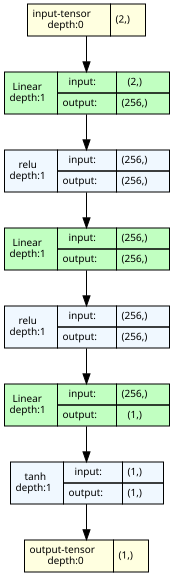

In [ ]:
actor_model_graph.visual_graph

In [ ]:
summary(aql.critic, input_size=[input_shape,action_shape])

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 64]             192
            Linear-2                   [-1, 64]           4,224
            Linear-3                  [-1, 256]          16,640
            Linear-4                  [-1, 256]          65,792
            Linear-5                    [-1, 1]             257
Total params: 87,105
Trainable params: 87,105
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.33
Estimated Total Size (MB): 0.34
----------------------------------------------------------------


In [ ]:
input_shape = np.expand_dims(np.asarray(state[0]), axis=0).shape
#input_shape = np.asarray(state[0]).shape
dummy_input = torch.randn(input_shape) # Create a dummy input tensor
dummy_action = aql.actor(dummy_input)
action_shape = dummy_action.detach().numpy().shape
print("input shape= ",input_shape)
print("action_shape= ", action_shape)

input shape=  (1, 2)
action_shape=  (1, 1)


In [ ]:
# Generate and display the graph
critic_model_graph = draw_graph(
    aql.critic,
    input_data=(dummy_input, dummy_action),
    graph_name='Critic',
    save_graph=False, # Set to True to save as file
    show_shapes=True,  # Displays input/output shapes
    expand_nested=True # Expand nested modules
)

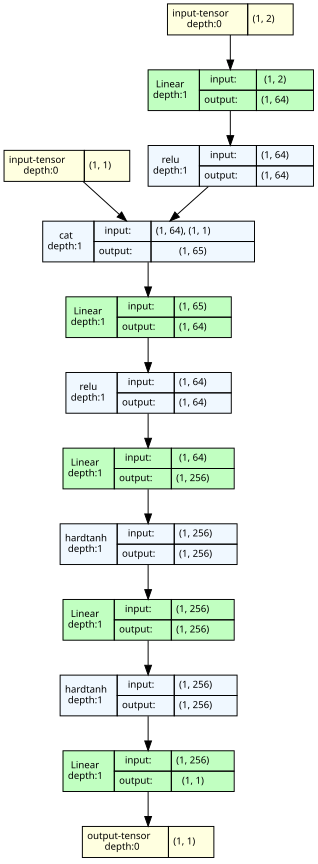

In [ ]:
critic_model_graph.visual_graph

In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/codes/Fixed PID Constants/save_data/Cont_Mount_Car/'

In [ ]:
#save_observation = []
#save_u1 = []
#save_pid_u1 = []
#save_ctrl_voltage = []

for i in range(aql.episodes):
    state = env.reset()
    state = np.asarray(state[0])
    s = np.expand_dims(state, axis=0)
    total_reward = 0
    done = False
    while not done:
      action = aql.act(torch.tensor(s, dtype = torch.float).unsqueeze(0)).item()
      next_state, reward, done, _ , force , u_after_pid= env.step(action) # self.state, reward, terminated, False , force , u_after_pid
      #if i == aql.episodes - 1 :
      #  save_observation.append(next_state)
      #  save_u1.append(force)
      #  save_pid_u1.append(u_after_pid)
      #  save_ctrl_voltage.append(env.DCMotorModel.voltage_input)

      #reward += -0.1*(env.goal_position-next_state[0])**2
      total_reward += reward
      #reward += 13 * abs(next_state[1])#*13

      aql.memory.push(state, action, next_state, reward)
      state = next_state
      s = np.expand_dims(state, axis=0) ####change
      aql.update()
    aql.eps *= 0.9
    score.appendleft(total_reward)
    # save best five episodes
    if i==0:
        np_mean_rewards = total_reward
    else:
        np_mean_rewards = np.mean(rewards)
    print(f'Episode {i},'
          f'total_reward: {total_reward:.3f},'
          f' mean five: {np.mean(score):.3f},'
          f' total mean {np_mean_rewards:.3f},'
          f' EPS: {aql.eps:.2e}')
    if np.mean(score) > best_score and i >= 5:
        torch.save(aql.actor, path+"model.pickle")
        best_score = np.mean(score)
        print('updated!!!!', f"{best_score:.3f}", '---------------------')
    rewards.append(total_reward)


Episode 0,total_reward: 86.663, mean five: 86.663, total mean 86.663, EPS: 9.00e-01
Episode 1,total_reward: -36.472, mean five: 25.095, total mean 86.663, EPS: 8.10e-01
Episode 2,total_reward: -41.228, mean five: 2.988, total mean 25.095, EPS: 7.29e-01
Episode 3,total_reward: 54.173, mean five: 15.784, total mean 2.988, EPS: 6.56e-01
Episode 4,total_reward: 72.019, mean five: 27.031, total mean 15.784, EPS: 5.90e-01
Episode 5,total_reward: -36.074, mean five: 2.483, total mean 27.031, EPS: 5.31e-01
updated!!!! 2.483 ---------------------
Episode 6,total_reward: -33.487, mean five: 3.080, total mean 16.513, EPS: 4.78e-01
updated!!!! 3.080 ---------------------
Episode 7,total_reward: -35.470, mean five: 4.232, total mean 9.370, EPS: 4.30e-01
updated!!!! 4.232 ---------------------
Episode 8,total_reward: -36.743, mean five: -13.951, total mean 3.765, EPS: 3.87e-01
Episode 9,total_reward: -64.951, mean five: -41.345, total mean -0.736, EPS: 3.49e-01
Episode 10,total_reward: 91.043, mean 

In [ ]:
# Test
#save_observation_temp = []
#save_u1_temp = []
#save_pid_u1_temp = []
#save_ctrl_voltage_temp = []
rewards_test = []
episode_length_test = []
total_episodes_test = 100
best_score = -1000
least_episode_length = 1000

In [ ]:
print('Test')
for i in range(total_episodes_test):
    state = env.reset()
    state = np.asarray(state[0])
    s = np.expand_dims(state, axis=0)
    save_observation_temp = [state]
    save_u1_temp = [0.0]
    save_pid_u1_temp = [0.0]
    save_ctrl_voltage_temp = []
    total_reward = 0
    done = False
    t_=0
    while not done:
      action = aql.act(torch.tensor(s, dtype = torch.float).unsqueeze(0)).item()
      next_state, reward, done, _ , force , u_after_pid= env.step(action) # self.state, reward, terminated, False , force , u_after_pid
      save_observation_temp.append(next_state)
      save_u1_temp.append(force)
      save_pid_u1_temp.append(u_after_pid)
      save_ctrl_voltage_temp.append(env.DCMotorModel.voltage_input)

      total_reward += reward

      state = next_state
      s = np.expand_dims(state, axis=0) ####change
      t_+=1

    episode_length_test.append(t_)
    save_ctrl_voltage_temp.append(env.DCMotorModel.voltage_input)
    # get best score and update save data
    print(f'Episode {i},'
          f'total_reward: {total_reward:.3f}, Episode Length {t_}')
    if best_score<total_reward and least_episode_length>t_:
      save_observation = list(save_observation_temp)
      save_u1 = list(save_u1_temp)
      save_pid_u1 = list(save_pid_u1_temp)
      save_ctrl_voltage = list(save_ctrl_voltage_temp)
      best_score = total_reward
      least_episode_length = t_
    rewards_test.append(total_reward)

Test
Episode 0,total_reward: 94.050, Episode Length 73
Episode 1,total_reward: 94.697, Episode Length 69
Episode 2,total_reward: 94.685, Episode Length 69
Episode 3,total_reward: 94.681, Episode Length 69
Episode 4,total_reward: 94.647, Episode Length 69
Episode 5,total_reward: 93.897, Episode Length 75
Episode 6,total_reward: 94.451, Episode Length 70
Episode 7,total_reward: 94.680, Episode Length 69
Episode 8,total_reward: 94.245, Episode Length 71
Episode 9,total_reward: 94.450, Episode Length 70
Episode 10,total_reward: 93.763, Episode Length 77
Episode 11,total_reward: 94.124, Episode Length 72
Episode 12,total_reward: 94.120, Episode Length 72
Episode 13,total_reward: 93.956, Episode Length 74
Episode 14,total_reward: 94.715, Episode Length 69
Episode 15,total_reward: 93.828, Episode Length 76
Episode 16,total_reward: 94.121, Episode Length 72
Episode 17,total_reward: 93.459, Episode Length 81
Episode 18,total_reward: 94.038, Episode Length 73
Episode 19,total_reward: 94.456, Epi

In [ ]:
save_observation_temp = None
save_u1_temp = None
save_pid_u1_temp = None
save_ctrl_voltage_temp = None

In [ ]:
# Create a dictionary of variables you want to save
variables_to_save = {
    'rewards': rewards,
    'save_observation': save_observation,
    'save_u1': save_u1,
    'save_pid_u1': save_pid_u1,
    'save_ctrl_voltage': save_ctrl_voltage,
    'aql': aql,
    'rewards_test': rewards_test,
    'episode_length_test':episode_length_test
}

In [ ]:
with open(path+'Cont_Moun_Car.pkl', 'wb') as f:
    pickle.dump(variables_to_save, f)
print(f"All variables saved to {path+'Cont_Moun_Car.pkl'}")

All variables saved to /content/drive/MyDrive/Colab Notebooks/codes/Fixed PID Constants/save_data/Cont_Mount_Car/Cont_Moun_Car.pkl


In [ ]:
# Open the file in read-binary mode and load the dictionary
with open(path+'Cont_Moun_Car.pkl', 'rb') as f:
    loaded_variables = pickle.load(f)

# Access the loaded variables
rewards = loaded_variables['rewards']
save_observation = loaded_variables['save_observation']
save_u1 = loaded_variables['save_u1']
save_pid_u1 = loaded_variables['save_pid_u1']
save_ctrl_voltage = loaded_variables['save_ctrl_voltage']
aql = loaded_variables['aql']
rewards_test = loaded_variables['rewards_test']
episode_length_test = loaded_variables['episode_length_test']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
aql.actor = torch.load(path+"model.pickle",weights_only=False).to(device)

In [ ]:
#Test(path+"model.pickle", rewards, 30).picture()

In [ ]:
plt.rc('text.latex', preamble=r'\usepackage{amsmath,amssymb,amsfonts}')
#plt.rcParams["text.usetex"]=False
#plt.rcParams["font.family"] = "sans-serif"
#plt.rcParams["font.family"] = "serif"
#plt.rcParams['mathtext.fontset'] = 'cm'
#plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

In [ ]:
def unnorm_to_norm(x):
  y = (x-low_bound_reward_list)/(up_bound_reward_list-low_bound_reward_list)
  return y

In [ ]:
def norm_to_unnorm(y):
  x=y*(up_bound_reward_list-low_bound_reward_list)+low_bound_reward_list
  return x

In [ ]:
low_bound_reward_list = -100 # -0.1*(1**2 force mag)*(1000*episoded)s
up_bound_reward_list = 100
print("low_bound_reward_list=",low_bound_reward_list)
print("up_bound_reward_list=",up_bound_reward_list)
norm_reward_list = np.array(rewards)
norm_reward_list = unnorm_to_norm(norm_reward_list)

low_bound_reward_list= -100
up_bound_reward_list= 100


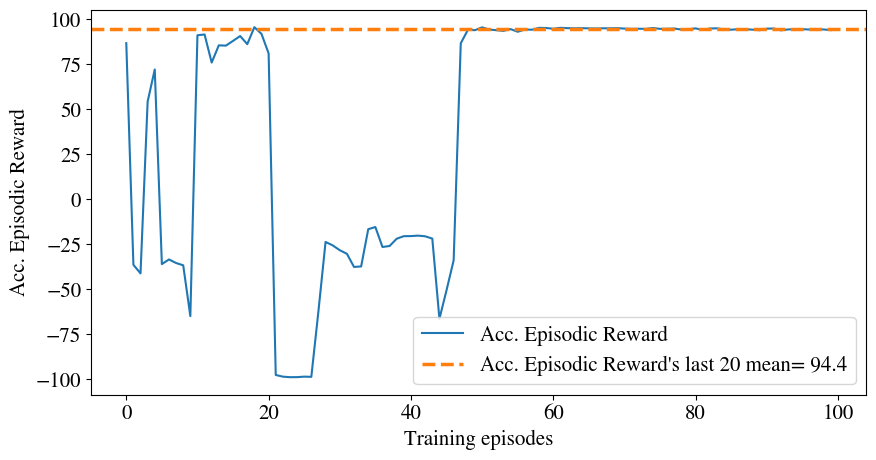

In [ ]:
import matplotlib.pyplot as plt

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
#plt.plot(plotting_rewards)
plt.plot(rewards, label = "Acc. Episodic Reward",color="C0",linewidth = 1.5)
plt.axhline(y=np.array(rewards)[-20:-1].mean(), linestyle='--',
            label = "Acc. Episodic Reward's last 20 mean= "+f"{np.array(rewards)[-20:-1].mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel('Training episodes',fontsize=15)
plt.ylabel('Acc. Episodic Reward',fontsize=15)
#plt.rc('axes', labelsize=30)

#plt.grid()
plt.legend()
#plt.title('Discrete_mountain_car',fontsize=20)
plt.show()

In [ ]:
print("Acc. Episodic Reward's last 20 mean=")
print(np.array(rewards[-20:-1]).mean())

Acc. Episodic Reward's last 20 mean=
94.37000429091921


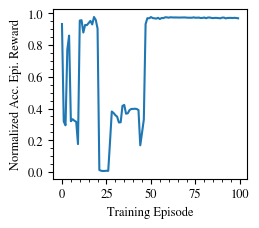

In [ ]:
# Episodes versus Norm Acc. Ep. Rewards
#norm_reward_list = np.array(rewards)
#norm_reward_list = (norm_reward_list/abs(norm_reward_list.min())+1)*100
#min_norm_reward_list = -100
#max_norm_reward_list= 100
#norm_reward_list = (norm_reward_list-min_norm_reward_list)/(max_norm_reward_list-min_norm_reward_list)

font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(2.5)
f.set_figheight(2.2)
plt.plot(norm_reward_list, label = "Normalized Acc. Epi. Reward",color="C0",linewidth = 1.5)
#plt.axhline(y=norm_reward_list[-20:-1].mean(), linestyle='--',
#            label = "Normalized Acc. Episodic Reward's last 20 mean= "+f"{norm_reward_list[-20:-1].mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Training Episode")
plt.ylabel("Normalized Acc. Epi. Reward")
#plt.grid()
#plt.legend()
plt.minorticks_on()
plt.savefig(path+"Cont_Mount_Car_Acc_Reward_vs_Episode.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
print("Normalized Acc. Epsiodic Reward's last 20 mean=")
print(norm_reward_list[-20:-1].mean())

Normalized Acc. Epsiodic Reward's last 20 mean=
0.971850021454596


In [ ]:
# Test Histogram
norm_ep_reward_list_test = np.array(rewards_test)
norm_ep_reward_list_test = unnorm_to_norm(norm_ep_reward_list_test)
print(norm_ep_reward_list_test.max())
print(norm_ep_reward_list_test.min())
min_bin = np.floor(norm_ep_reward_list_test.min()*100)/100
print(min_bin)

0.9738600183708626
0.9664332266097523
0.96


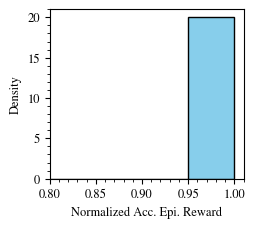

In [ ]:
font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(2.5)
f.set_figheight(2.2)
data_rewards = np.array(norm_ep_reward_list_test)
density_True = True
plt.hist(data_rewards, bins=np.arange(0,1.01,0.05),density=density_True ,color='skyblue', edgecolor='black')
plt.xlabel('Normalized Acc. Epi. Reward')
ylabel='Density'if density_True else 'Frequency'
plt.ylabel(ylabel)
#plt.xticks(np.arange(0,1.1,0.2))
plt.xlim((0.80,1.01))
plt.minorticks_on()
plt.savefig(path+"Cont_Mount_Car_Acc_Reward_vs_Episode_Test_Hist.pdf", format='pdf', bbox_inches='tight')
plt.show()

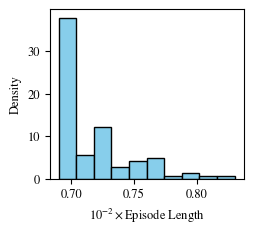

In [ ]:
font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(2.5)
f.set_figheight(2.2)
data_episode_length_test = np.array(episode_length_test)/100
density_True = True
plt.hist(data_episode_length_test, density=density_True ,color='skyblue', edgecolor='black')
plt.xlabel(r'$10^{-2}\times$Episode Length')
ylabel='Density'if density_True else 'Frequency'
plt.ylabel(ylabel)
#plt.xticks(np.arange(65,165,5))
plt.savefig(path+"Cont_Mount_Car_Acc_Episode_Length_vs_Episode_Test_Hist.pdf", format='pdf', bbox_inches='tight')
plt.show()

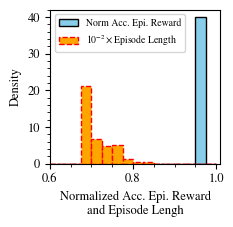

In [ ]:
font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(2.2)
f.set_figheight(2.0)
data_rewards = np.array(norm_ep_reward_list_test)
density_True = True
plt.hist(data_rewards, bins = np.arange(0,1.0001,0.025), density=density_True,label="Norm Acc. Epi. Reward" ,color='skyblue', edgecolor='black')
data_episode_length_test = np.array(episode_length_test)
plt.hist(data_episode_length_test/100,bins = np.arange(0,1.0001,0.025),
         density=density_True,label=r'$10^{-2}\times$Episode Length',
         color='orange', edgecolor='red',
         linewidth=1, linestyle='--')
plt.xlabel('Normalized Acc. Epi. Reward\nand Episode Lengh')
ylabel='Density'if density_True else 'Frequency'
plt.ylabel(ylabel)
#plt.xticks(np.arange(0,1.00001,0.05),minor=True)
plt.minorticks_on()
plt.xlim((0.6,1.01))
plt.legend(fontsize=7)
plt.savefig(path+"Cont_Mount_Car_Acc_Reward_and_Length_vs_Episode_Test_Hist.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
print("Test Normalized Acc Episodic Reward's Results:")
print(f"Unnormalized: max={norm_to_unnorm(data_rewards).max():.3f} ,mean={norm_to_unnorm(data_rewards).mean():.3f}, std={norm_to_unnorm(data_rewards).std():.3f}")
print(f"Normalized:   max={data_rewards.max():.3e} ,mean={data_rewards.mean():.3e}, std={data_rewards.std():.3e}")

Test Normalized Acc Episodic Reward's Results:
Unnormalized: max=94.772 ,mean=94.283, std=0.335
Normalized:   max=9.739e-01 ,mean=9.714e-01, std=1.675e-03


In [ ]:
print("Test Episode Lenght's Results:")
print(f"min={data_episode_length_test.min():.3f} ,mean={data_episode_length_test.mean():.3f}, std={data_episode_length_test.std():.3f}")

Test Episode Lenght's Results:
min=69.000 ,mean=71.630, std=2.975


In [ ]:
dt=env.tau

time_position_u1= np.linspace(start = 0, stop = len(save_u1)*dt,num=len(save_u1) ) # 1/1000=0.001
time_position__pid_u1= np.linspace(start = 0, stop = len(save_u1)*dt,num=len(save_u1) )

e_ry=np.array(save_u1)-np.array(save_pid_u1)
mean_std=f'(mean,std)=({e_ry.mean():.2e}, {e_ry.std():.2e})'

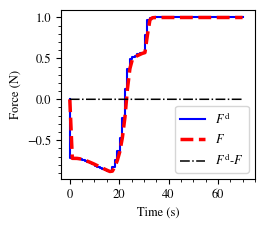

In [ ]:

font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(2.5)
f.set_figheight(2.2)

plt.step(time_position_u1, save_u1 ,label = r"$F^\mathrm{d}$",color="blue",linewidth = 1.5)
plt.plot(time_position__pid_u1, np.array(save_pid_u1), '--',label = r"$F$",color="red",linewidth = 2.5)
plt.plot(time_position_u1, e_ry,'-.',label = r"$F^\mathrm{d}$-$F$",color="black",linewidth = 1.1)

plt.xlabel("Time (s)")
plt.ylabel("Force (N)")
#plt.grid()
plt.legend()
plt.minorticks_on()
plt.xticks(np.arange(0,time_position_u1[-1]+10,5),minor=True)
plt.savefig(path+"Cont_Mount_Car_Force_vs_Time.pdf", format='pdf', bbox_inches='tight')

plt.show()

In [ ]:
print(mean_std)

(mean,std)=(-4.83e-06, 3.83e-05)


In [ ]:
print(f"mae={np.abs(e_ry).mean():.3e}")

mae=1.335e-05


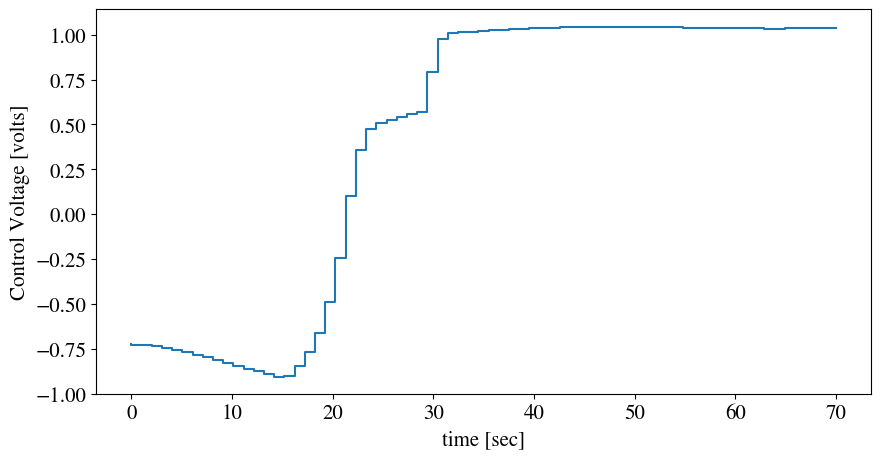

In [ ]:
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.step(time_position_u1, save_ctrl_voltage)
plt.xlabel("time [sec]")
plt.ylabel("Control Voltage [volts]")
#plt.grid()
plt.show()

In [ ]:
import math

position = []   #position of the car along the x-axis
velocity = []   #velocity of the car

for observ in save_observation:
  for index,value in enumerate(observ):
    if index == 0:
      position.append(value)

    if index == 1:
      velocity.append(value)

In [ ]:
print(len(position))

70


In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_x_position = np.linspace(start = 0, stop = len(position)* dt ,num=len(position))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_x_position[-1] , 300)

spl = make_interp_spline(time_x_position, position, k=3)  # type: BSpline
power_smooth = spl(xnew)



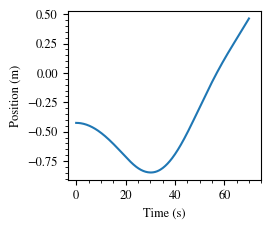

In [ ]:
font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(2.5)
f.set_figheight(2.2)

plt.plot(xnew, power_smooth)
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
#plt.grid()
plt.minorticks_on()
plt.xticks(np.arange(0,time_position_u1[-1]+10,5),minor=True)
plt.savefig(path+"Cont_Mount_Position_vs_Time.pdf", format='pdf', bbox_inches='tight')
plt.show()

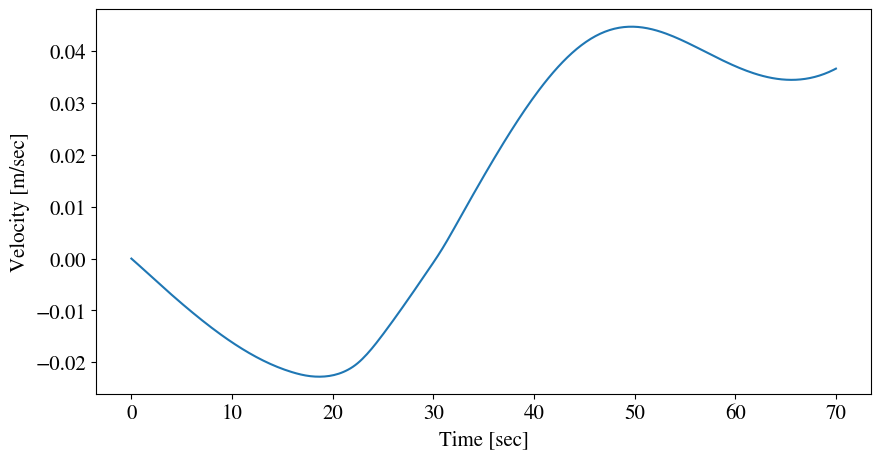

In [ ]:
time_velocity = np.linspace(start = 0, stop = len(velocity)* dt ,num=len(velocity))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_velocity[-1] , 300)

spl = make_interp_spline(time_velocity, velocity, k=3)  # type: BSpline
power_smooth = spl(xnew)

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.plot(xnew, power_smooth)
plt.xlabel("Time [sec]")
plt.ylabel("Velocity [m/sec]")
#plt.grid()
plt.show()